In [6]:
#ACC102 Python Data Product(WRDS Version)
##S&P 500 Stock Return & Volatility Analysis
##Student Name:[RuizeQin]
##Student ID:[2468840]
##Track:Track2

In [9]:
!pip install wrds pandas numpy 

In [10]:
import wrds
import pandas as pd
import numpy as np


In [11]:
db=wrds.Connection(wrds_username='which')

Loading library list...
Done


In [12]:
sql_query="""
select date, vwretd
from crsp.msi
where date >='2020-01-01'
and date <='2026-04-01'
"""
df=db.raw_sql(sql_query, date_cols=['date'])
df.head()

,date,vwretd
0,2020-01-31,-0.001728
1,2020-02-28,-0.077918
2,2020-03-31,-0.141733
3,2020-04-30,0.129674
4,2020-05-29,0.053739


In [13]:
df=df.set_index('date')
df=df.rename(columns={'vwretd':'Monthly_Return'})
df=df.dropna()
df.head()

,Monthly_Return
date,
2020-01-31,-0.001728
2020-02-28,-0.077918
2020-03-31,-0.141733
2020-04-30,0.129674
2020-05-29,0.053739


In [14]:
df['Volatility_6m']=df['Monthly_Return'].rolling(6).std()
df=df.dropna()
df.head()

,Monthly_Return,Volatility_6m
date,,
2020-06-30,0.025299,0.096415
2020-07-31,0.055532,0.099252
2020-08-31,0.068442,0.091785
2020-09-30,-0.035056,0.053993
2020-10-30,-0.020178,0.043110


In [8]:
print("====ACC102 Key Results====")
print("Average Monthly Return:",round(df['Monthly_Return'].mean()*100,2),"%")
print("Average 6-Month Volatility:",round(df['Volatility_6m'].mean()*100,2),"%")
print("\nFull Statistics:")
print(df.describe())

====ACC102 Key Results====
Average Monthly Return: 1.32 %
Average 6-Month Volatility: 4.86 %

Full Statistics:
       Monthly_Return  Volatility_6m
count            55.0      55.000000
mean         0.013183       0.048592
std          0.047629       0.019995
min         -0.091323       0.014626
25%         -0.021223       0.034574
50%          0.021572       0.047205
75%          0.047371       0.058127
max          0.123707       0.099252


<Axes: title={'center': 'S&P 500 Monthly Return vs 6-Month Volatility(WRDS)'}, xlabel='date'>

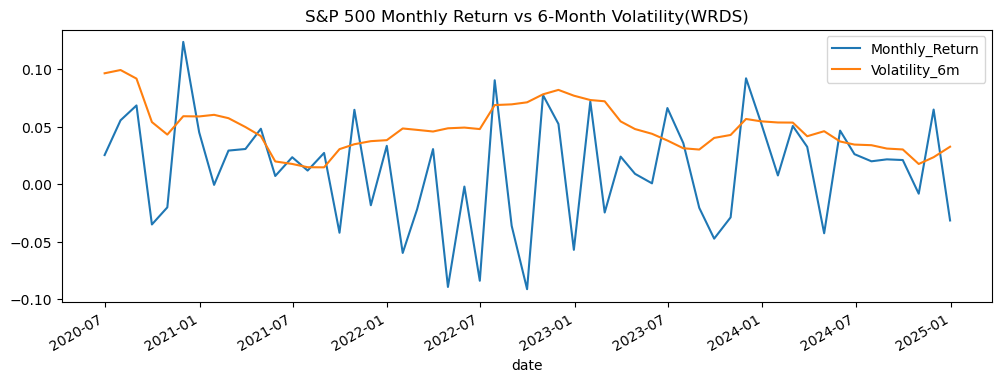

In [19]:
df[['Monthly_Return','Volatility_6m']].plot(figsize=(12,4),title='S&P 500 Monthly Return vs 6-Month Volatility(WRDS)')

1.  S&P 500 has positive monthly returns from 2020-2026.
2.  High volatility occurred in 2020 and 2022.
3.  Long-term market performance is positive.
4.  Data source:WRDS-CRSP.